In [13]:
# import cv2
# import numpy as np
#
# # ---------------------- 核心函数：Harris 角点检测（提取特征点，修复 KeyPoint 错误）----------------------
# def harris_corner_extract(gray_img, block_size=2, ksize=3, k=0.04, threshold=0.01):
#     """
#     提取图像 Harris 角点，返回可用的关键点格式（适配 ORB 特征匹配，修复 KeyPoint 兼容问题）
#     """
#     # 1. 格式转换，满足 Harris 输入要求
#     gray_float = np.float32(gray_img)
#
#     # 2. 调用 OpenCV Harris 角点检测
#     harris_dst = cv2.cornerHarris(gray_float, blockSize=block_size, ksize=ksize, k=k)
#
#     # 3. 膨胀增强响应区域，阈值筛选高置信度角点
#     harris_dst = cv2.dilate(harris_dst, None)
#     harris_thresh = threshold * harris_dst.max()
#
#     # 4. 提取角点坐标，转换为 OpenCV KeyPoint 格式（修复：明确参数名，兼容高版本 OpenCV）
#     corners = []
#     h, w = gray_img.shape
#     for y in range(h):
#         for x in range(w):
#             if harris_dst[y, x] > harris_thresh:
#                 # 修复核心：明确指定 x、y、size 参数名，去掉下划线，兼容 OpenCV 4.12.0
#                 kp = cv2.KeyPoint(x=float(x), y=float(y), size=10.0)
#                 corners.append(kp)
#
#     return corners
#
# # ---------------------- 核心函数：两张图片拼接（全景图生成）----------------------
# def stitch_two_images(img1_path, img2_path):
#     """
#     读取两张本地图片，完成角点检测→特征匹配→图像拼接
#     img1_path: 第一张图片路径（如 "img1.jpg"）
#     img2_path: 第二张图片路径（如 "img2.jpg"）
#     """
#     # 1. 读取两张本地图片（彩色图）
#     img1 = cv2.imread(img1_path)
#     img2 = cv2.imread(img2_path)
#
#     # 容错：判断图片是否读取成功
#     if img1 is None or img2 is None:
#         raise Exception("图片读取失败！请检查图片路径是否正确，或图片格式是否支持（jpg/png 等）")
#
#     # 2. 图像预处理：灰度化 + 高斯模糊降噪（提升角点检测精度）
#     gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
#     gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
#     gray1_blur = cv2.GaussianBlur(gray1, (5, 5), 0)
#     gray2_blur = cv2.GaussianBlur(gray2, (5, 5), 0)
#
#     # 3. Harris 角点检测：提取两张图的特征关键点
#     kp1 = harris_corner_extract(gray1_blur)
#     kp2 = harris_corner_extract(gray2_blur)
#     print(f"第一张图提取到 {len(kp1)} 个 Harris 角点")
#     print(f"第二张图提取到 {len(kp2)} 个 Harris 角点")
#
#     # 4. 特征描述：用 ORB 算法为角点生成特征描述子（实现角点匹配）
#     orb = cv2.ORB_create()
#     kp1, des1 = orb.compute(gray1_blur, kp1)
#     kp2, des2 = orb.compute(gray2_blur, kp2)
#
#     # 5. 特征匹配：暴力匹配器筛选优质匹配点
#     bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
#     matches = bf.match(des1, des2)
#     # 按匹配距离排序，取前 100 个优质匹配（距离越小，匹配度越高）
#     matches = sorted(matches, key=lambda x: x.distance)[:100]
#
#     # 6. 计算单应性矩阵（实现图像配准，RANSAC 算法去除异常匹配）
#     pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
#     pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
#     H, mask = cv2.findHomography(pts2, pts1, cv2.RANSAC, 5.0)
#
#     # 7. 图像变换与拼接：将 img2 映射到 img1 坐标空间，生成全景图
#     h1, w1 = img1.shape[:2]
#     h2, w2 = img2.shape[:2]
#     # 计算拼接后图像的尺寸（避免内容被裁剪）
#     img2_warped = cv2.warpPerspective(img2, H, (w1 + w2, h1))
#     # 融合两张图像，完成拼接
#     img2_warped[:h1, :w1] = img1
#     # 优化：去除右侧多余的黑色背景（仅保留有效内容）
#     stitch_result = img2_warped[:h1, :np.max(np.where(img2_warped.sum(axis=2) > 0)[1])]
#
#     # 8. 可选：生成匹配结果可视化图（查看角点匹配效果）
#     match_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
#
#     return stitch_result, match_img
#
# # ---------------------- 主流程：运行拼接（替换为你的两张图片路径即可）----------------------
# if __name__ == "__main__":
#     # ********** 替换这里为你的两张图片路径 **********
#     IMG_PATH_1 = "your_img1.jpg"  # 第一张图（如左侧图）
#     IMG_PATH_2 = "your_img2.jpg"  # 第二张图（如右侧图，与第一张有重叠）
#
#     try:
#         # 执行拼接
#         final_stitch, match_vis = stitch_two_images(IMG_PATH_1, IMG_PATH_2)
#         print("图像拼接成功！")
#
#         # 可视化结果（OpenCV 窗口，支持缩放）
#         cv2.namedWindow("角点匹配效果", cv2.WINDOW_NORMAL)
#         cv2.namedWindow("最终拼接结果", cv2.WINDOW_NORMAL)
#         cv2.imshow("角点匹配效果", match_vis)
#         cv2.imshow("最终拼接结果", final_stitch)
#
#         # 等待按键关闭窗口
#         cv2.waitKey(0)
#         cv2.destroyAllWindows()
#
#         # 保存结果到当前目录（可选）
#         cv2.imwrite("角点匹配可视化.jpg", match_vis)
#         cv2.imwrite("最终拼接全景图.jpg", final_stitch)
#         print("结果已保存到当前目录！")
#
#     except Exception as e:
#         print(f"运行出错：{e}")

开始执行 img1 与 img2 的拼接...
第一张图提取到 8447 个 Harris 角点
第二张图提取到 12966 个 Harris 角点
img1 与 img2 图像拼接成功！


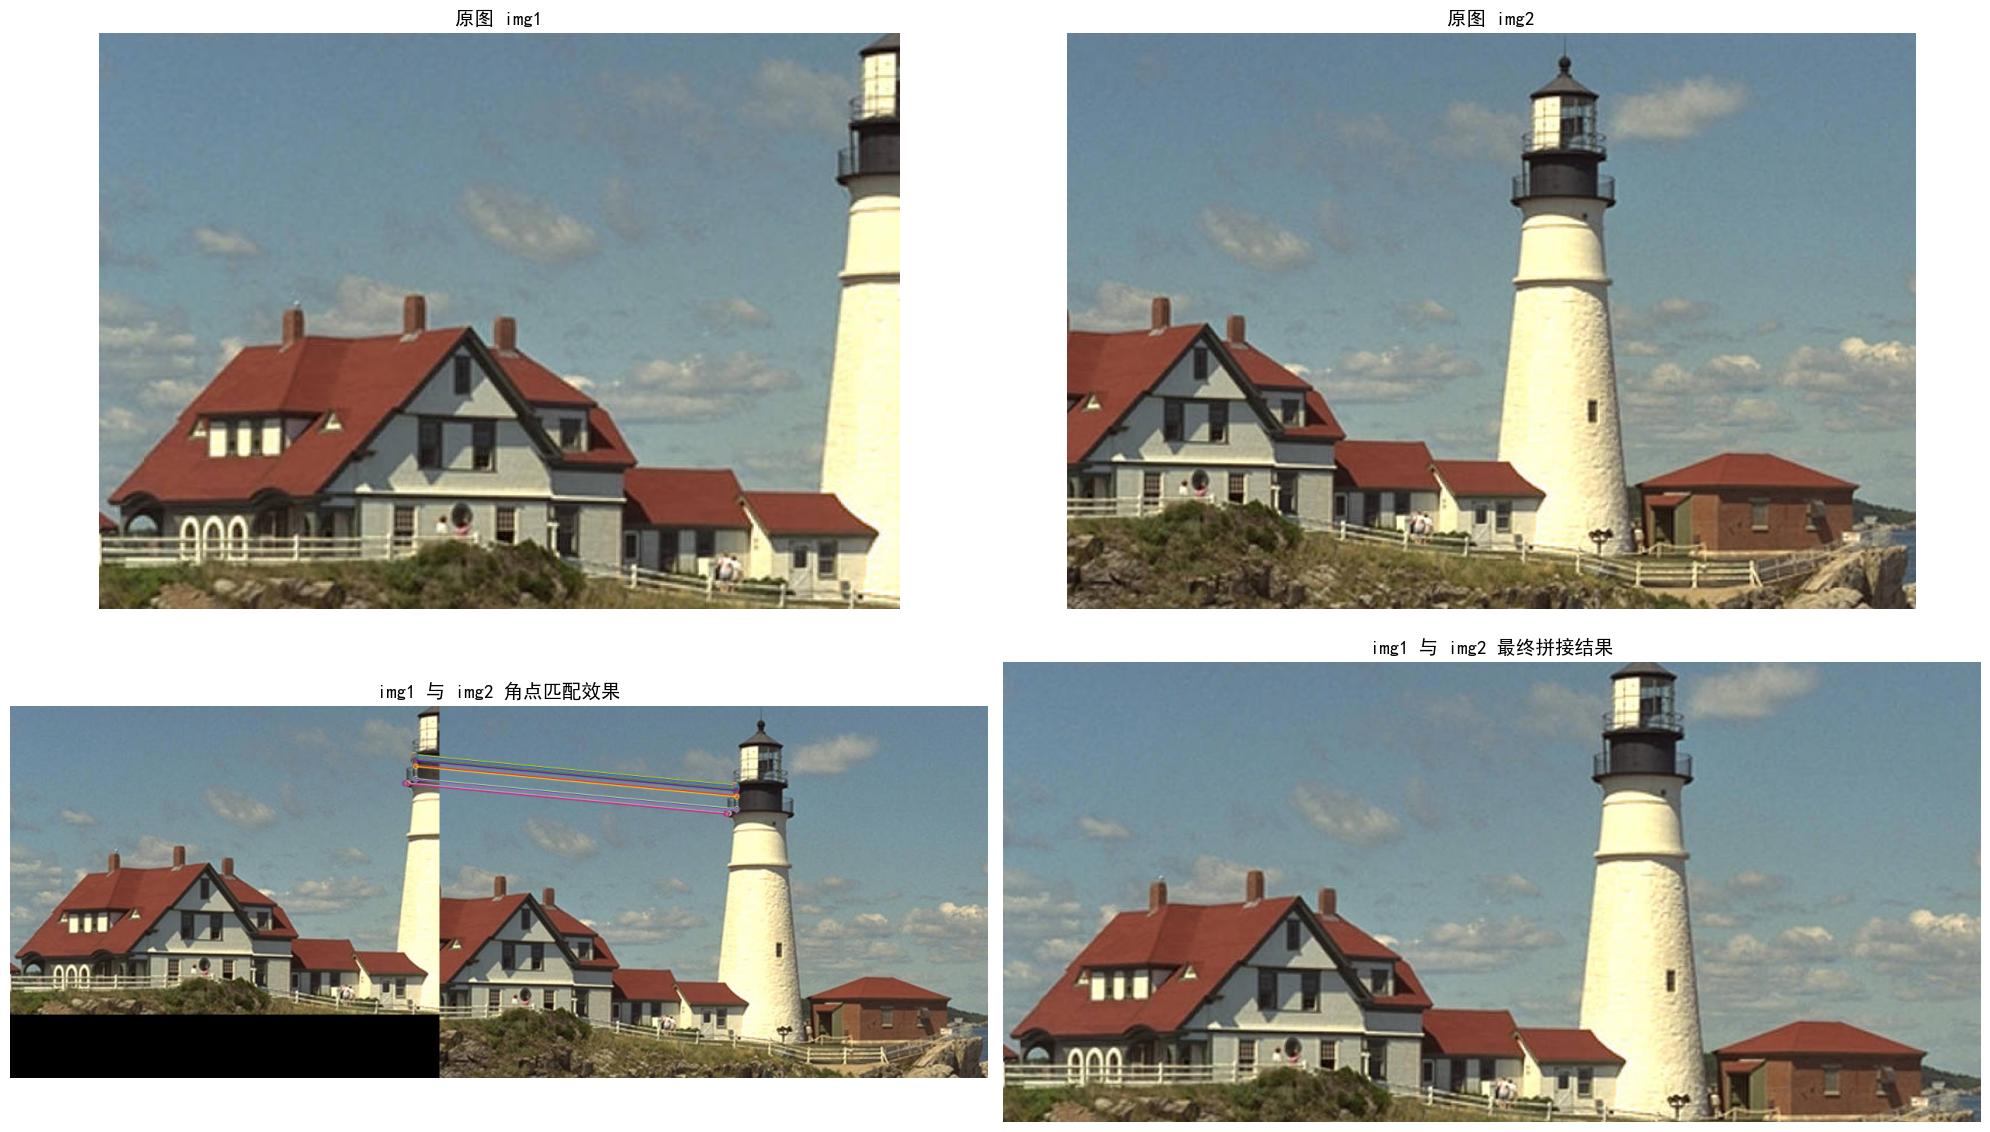

img1 与 img2 可视化完成（不保存本地文件）！
开始执行 img1 与 img3 的拼接...
第一张图提取到 8447 个 Harris 角点
第二张图提取到 6518 个 Harris 角点
img1 与 img3 图像拼接成功！


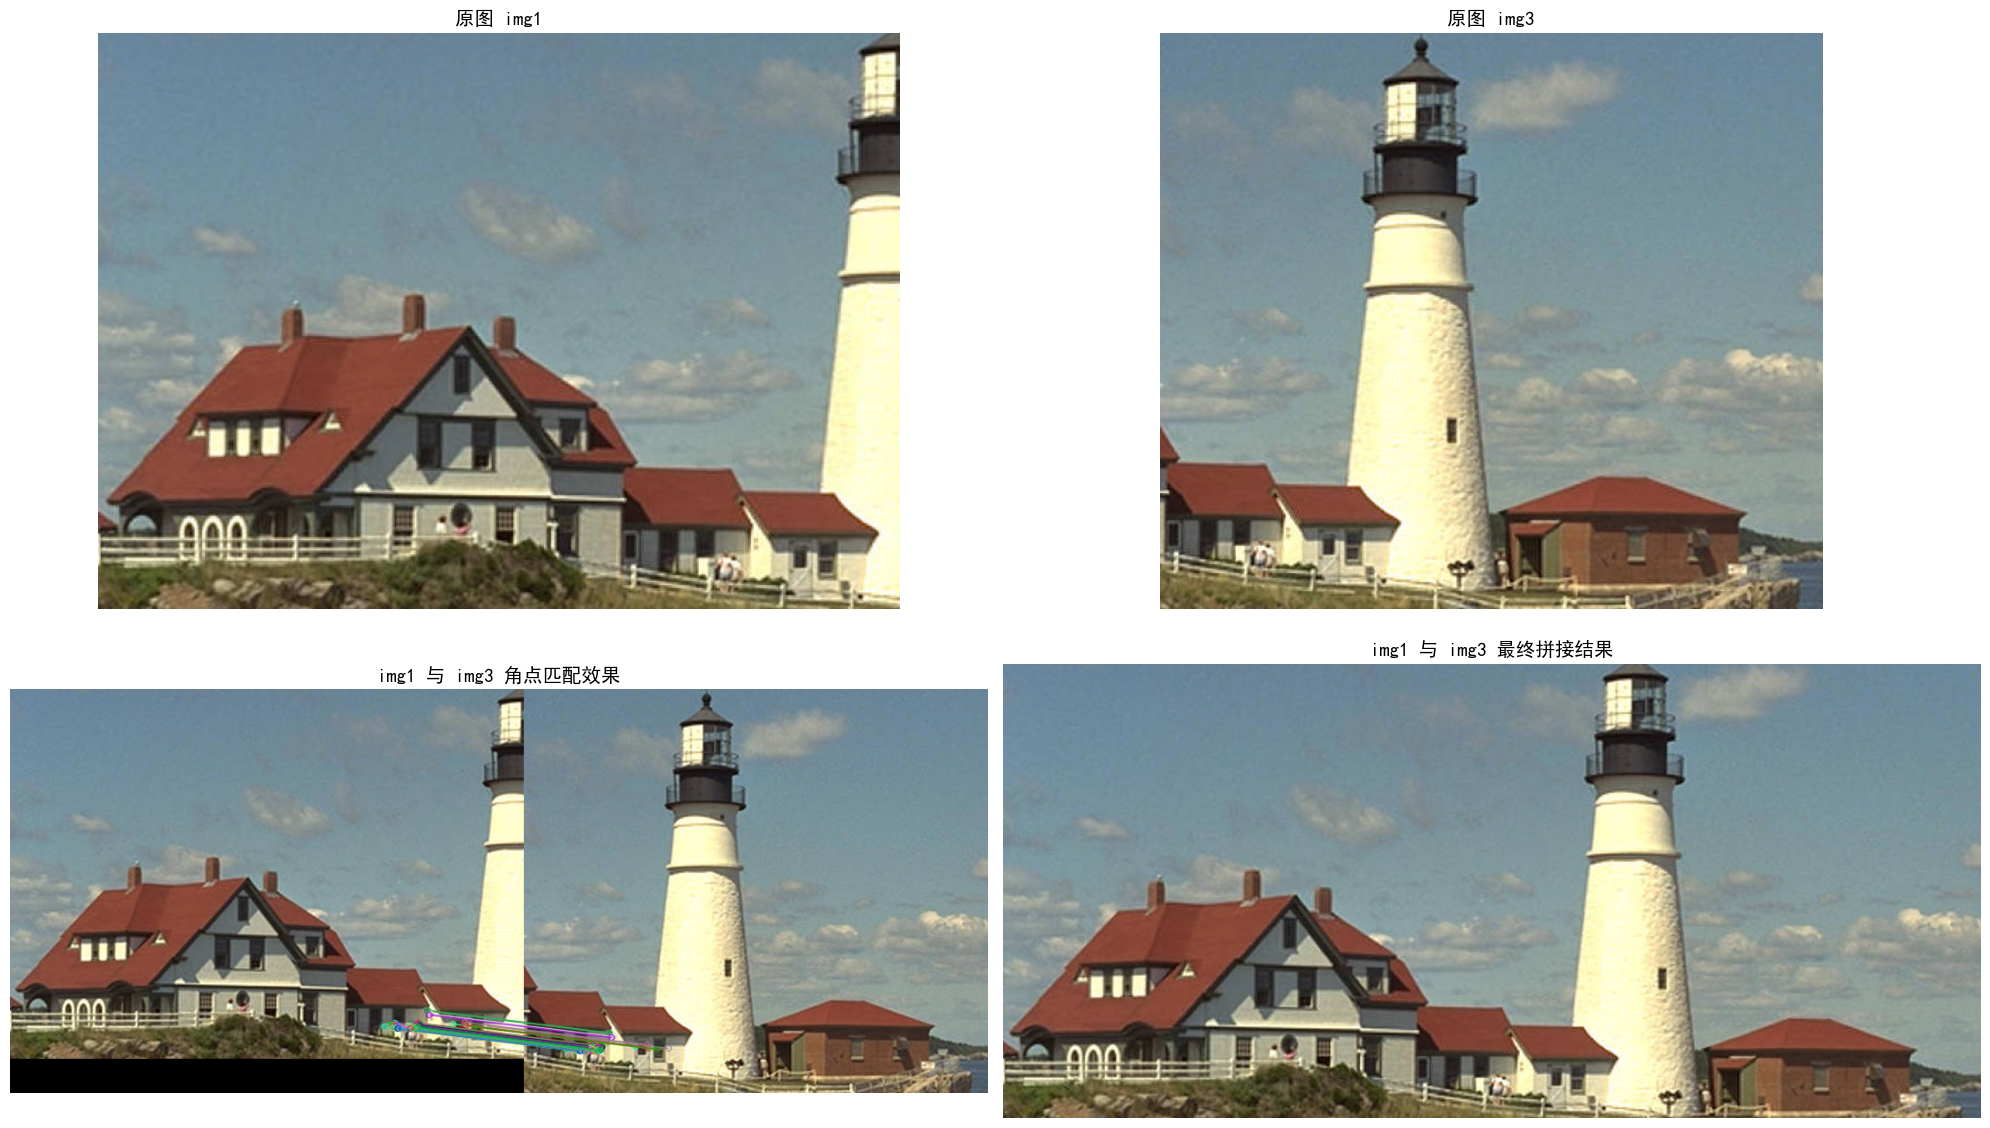

img1 与 img3 可视化完成（不保存本地文件）！


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- 全局配置：解决 Matplotlib 中文乱码 + 图像格式转换 ----------------------
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 指定支持中文的黑体字体
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示为方块的问题

def cv2_to_plt(img):
    """将 OpenCV BGR 格式图像转换为 Matplotlib 可显示的 RGB 格式"""
    if len(img.shape) == 3:  # 彩色图需要转换
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:  # 灰度图无需转换
        return img

# ---------------------- 核心函数：Harris 角点检测（你的正确逻辑，完全保留）----------------------
def harris_corner_extract(gray_img, block_size=2, ksize=3, k=0.04, threshold=0.01):
    """
    提取图像 Harris 角点，返回可用的关键点格式（适配 ORB 特征匹配，修复 KeyPoint 兼容问题）
    """
    # 1. 格式转换，满足 Harris 输入要求
    gray_float = np.float32(gray_img)

    # 2. 调用 OpenCV Harris 角点检测
    harris_dst = cv2.cornerHarris(gray_float, blockSize=block_size, ksize=ksize, k=k)

    # 3. 膨胀增强响应区域，阈值筛选高置信度角点
    harris_dst = cv2.dilate(harris_dst, None)
    harris_thresh = threshold * harris_dst.max()

    # 4. 提取角点坐标，转换为 OpenCV KeyPoint 格式（修复：明确参数名，兼容高版本 OpenCV）
    corners = []
    h, w = gray_img.shape
    for y in range(h):
        for x in range(w):
            if harris_dst[y, x] > harris_thresh:
                # 修复核心：明确指定 x、y、size 参数名，去掉下划线，兼容 OpenCV 4.12.0
                kp = cv2.KeyPoint(x=float(x), y=float(y), size=10.0)
                corners.append(kp)

    return corners

# ---------------------- 核心函数：两张图片拼接（你的正确逻辑，完全保留，移除保存相关）----------------------
def stitch_two_images(img1_path, img2_path):
    """
    读取两张本地图片，完成角点检测→特征匹配→图像拼接
    img1_path: 第一张图片路径（如 "img1.jpg"）
    img2_path: 第二张图片路径（如 "img2.jpg"）
    """
    # 1. 读取两张本地图片（彩色图）
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)

    # 容错：判断图片是否读取成功
    if img1 is None or img2 is None:
        raise Exception("图片读取失败！请检查图片路径是否正确，或图片格式是否支持（jpg/png 等）")

    # 2. 图像预处理：灰度化 + 高斯模糊降噪（提升角点检测精度）
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    gray1_blur = cv2.GaussianBlur(gray1, (5, 5), 0)
    gray2_blur = cv2.GaussianBlur(gray2, (5, 5), 0)

    # 3. Harris 角点检测：提取两张图的特征关键点
    kp1 = harris_corner_extract(gray1_blur)
    kp2 = harris_corner_extract(gray2_blur)
    print(f"第一张图提取到 {len(kp1)} 个 Harris 角点")
    print(f"第二张图提取到 {len(kp2)} 个 Harris 角点")

    # 4. 特征描述：用 ORB 算法为角点生成特征描述子（实现角点匹配）
    orb = cv2.ORB_create()
    kp1, des1 = orb.compute(gray1_blur, kp1)
    kp2, des2 = orb.compute(gray2_blur, kp2)

    # 5. 特征匹配：暴力匹配器筛选优质匹配点
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    # 按匹配距离排序，取前 100 个优质匹配（距离越小，匹配度越高）
    matches = sorted(matches, key=lambda x: x.distance)[:100]

    # 6. 计算单应性矩阵（实现图像配准，RANSAC 算法去除异常匹配）
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(pts2, pts1, cv2.RANSAC, 5.0)

    # 7. 图像变换与拼接：将 img2 映射到 img1 坐标空间，生成全景图
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    # 计算拼接后图像的尺寸（避免内容被裁剪）
    img2_warped = cv2.warpPerspective(img2, H, (w1 + w2, h1))
    # 融合两张图像，完成拼接
    img2_warped[:h1, :w1] = img1
    # 优化：去除右侧多余的黑色背景（仅保留有效内容）
    stitch_result = img2_warped[:h1, :np.max(np.where(img2_warped.sum(axis=2) > 0)[1])]

    # 8. 可选：生成匹配结果可视化图（查看角点匹配效果）
    match_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    return stitch_result, match_img, img1, img2  # 额外返回原图，方便可视化对比

# ---------------------- 主流程：Jupyter Notebook 专属可视化（无保存，无 OpenCV 弹窗）----------------------
# ********** 替换这里为你的三张图片路径 **********
IMG_PATH_1 = "img1.jpg"  # 基准图：分别和 img2、img3 拼接
IMG_PATH_2 = "img2.jpg"  # 与 img1 重叠的图2
IMG_PATH_3 = "img3.jpg"  # 与 img1 重叠的图3

# ---------------------- 第一步：img1 与 img2 拼接 + Matplotlib 可视化 ----------------------
print("="*50)
print("开始执行 img1 与 img2 的拼接...")
try:
    stitch_12, match_12, img1, img2 = stitch_two_images(IMG_PATH_1, IMG_PATH_2)
    print("img1 与 img2 图像拼接成功！")

    # ---------- Matplotlib 可视化：img1&img2 对比 + 匹配效果 + 拼接结果 ----------
    plt.figure(figsize=(20, 12))

    # 子图1：原图 img1
    plt.subplot(2, 2, 1)
    plt.imshow(cv2_to_plt(img1))
    plt.title("原图 img1", fontsize=14)
    plt.axis("off")

    # 子图2：原图 img2
    plt.subplot(2, 2, 2)
    plt.imshow(cv2_to_plt(img2))
    plt.title("原图 img2", fontsize=14)
    plt.axis("off")

    # 子图3：角点匹配效果
    plt.subplot(2, 2, 3)
    plt.imshow(cv2_to_plt(match_12))
    plt.title("img1 与 img2 角点匹配效果", fontsize=14)
    plt.axis("off")

    # 子图4：最终拼接结果
    plt.subplot(2, 2, 4)
    plt.imshow(cv2_to_plt(stitch_12))
    plt.title("img1 与 img2 最终拼接结果", fontsize=14)
    plt.axis("off")

    plt.tight_layout()  # 自动调整子图间距，避免重叠
    plt.show()

    # 【已删除】保存结果相关代码，不再生成本地文件
    print("img1 与 img2 可视化完成（不保存本地文件）！")

except Exception as e:
    print(f"img1 与 img2 拼接出错：{e}")

# ---------------------- 第二步：img1 与 img3 拼接 + Matplotlib 可视化 ----------------------
print("="*50)
print("开始执行 img1 与 img3 的拼接...")
try:
    stitch_13, match_13, img1, img3 = stitch_two_images(IMG_PATH_1, IMG_PATH_3)
    print("img1 与 img3 图像拼接成功！")

    # ---------- Matplotlib 可视化：img1&img3 对比 + 匹配效果 + 拼接结果 ----------
    plt.figure(figsize=(20, 12))

    # 子图1：原图 img1
    plt.subplot(2, 2, 1)
    plt.imshow(cv2_to_plt(img1))
    plt.title("原图 img1", fontsize=14)
    plt.axis("off")

    # 子图2：原图 img3
    plt.subplot(2, 2, 2)
    plt.imshow(cv2_to_plt(img3))
    plt.title("原图 img3", fontsize=14)
    plt.axis("off")

    # 子图3：角点匹配效果
    plt.subplot(2, 2, 3)
    plt.imshow(cv2_to_plt(match_13))
    plt.title("img1 与 img3 角点匹配效果", fontsize=14)
    plt.axis("off")

    # 子图4：最终拼接结果
    plt.subplot(2, 2, 4)
    plt.imshow(cv2_to_plt(stitch_13))
    plt.title("img1 与 img3 最终拼接结果", fontsize=14)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # 【已删除】保存结果相关代码，不再生成本地文件
    print("img1 与 img3 可视化完成（不保存本地文件）！")

except Exception as e:
    print(f"img1 与 img3 拼接出错：{e}")